# J04 — Écoulement de l'eau en sol saturé

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 4 : perméamètres, sol stratifié, écartement de drains (Hooghoudt), Laplace 2D par différences finies*

> Version **instructeur** : code complet et résultats.

## Mise en place

Unités : cm et jours pour les sols (convention du cours et de HYDRUS-1D), m et jours pour le drainage et Laplace 2D.
$z$ positif vers le haut, $q > 0$ vers le haut, $H = h + z$. Exécutez la cellule suivante pour importer les bibliothèques
et définir la viscosité de l'eau (table en fonction de la température).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rho_w = 998.2   # masse volumique de l'eau, kg/m³
g_pes = 9.81    # accélération de la pesanteur, m/s²

T_table = np.array([5, 10, 15, 18, 20, 25, 30])                                     # °C
mu_table = np.array([1.519, 1.307, 1.139, 1.053, 1.002, 0.890, 0.798]) * 1e-3      # Pa s

# viscosité dynamique de l'eau (Pa s) par interpolation linéaire dans la table
def viscosite(T):
    return np.interp(T, T_table, mu_table)

## Exercice 1 — Perméamètres à charge constante et à charge variable  *(≈ 15 min)*

1. `data/J04_permeametre_charge_constante.csv` : quatre échantillons (S1–S4) mesurés trois fois chacun à 18 °C
   ($L$, $A$, $\Delta H$, volume $V$ recueilli en $t$). Calculer $K_s = V L/(A\,\Delta H\,t)$ pour chaque essai (cm/s), ramener à
   20 °C ($K_s(20) = K_s(T)\,\mu(T)/\mu(20)$) et convertir en cm/j et m/s ; puis calculer la moyenne, l'écart type et le
   coefficient de variation par échantillon.
2. `data/J04_permeametre_charge_variable.csv` : lectures $h(t)$ pour deux échantillons (colonnes `a_cm2`, `A_cm2`, `L_cm`).
   Comme $\ln h = \ln h_0 - (A K_s/aL)\,t$, ajuster une droite sur $\ln h$ en fonction de $t$ (`np.polyfit(t, np.log(h), 1, cov=True)`) ;
   en déduire $K_s$ et son erreur type ; tracer les points et la droite.
3. Comparer les $K_s$ mesurées à l'estimation de Kozeny–Carman, $K_s = (\rho_w g/\mu)\, n^3 d^2/[180(1-n)^2]$ avec $d = d_{10}$,
   pour S1–S4 (colonnes `d10_mm`, `n`). Commenter les écarts.

**Lecture des données**

In [2]:
cc = pd.read_csv("data/J04_permeametre_charge_constante.csv")
cv = pd.read_csv("data/J04_permeametre_charge_variable.csv")
print(cc)
print(cv.head(8))
print("Nombre de lectures h(t) par échantillon :")
print(cv.groupby("echantillon")["t_s"].count())

   echantillon       texture  repetition  L_cm   A_cm2  dH_cm  V_cm3   t_s  \
0           S1   sable moyen           1  10.0  19.635   20.0   50.3    60   
1           S1   sable moyen           2  10.0  19.635   10.0   26.5    60   
2           S1   sable moyen           3  10.0  19.635   20.0   52.7    60   
3           S2     sable fin           1  10.0  19.635   15.0   23.3   120   
4           S2     sable fin           2  10.0  19.635   20.0   33.3   120   
5           S2     sable fin           3  10.0  19.635   10.0   14.4   120   
6           S3  loam sableux           1  10.0  19.635   15.0   19.0   600   
7           S3  loam sableux           2  10.0  19.635   10.0   12.8   600   
8           S3  loam sableux           3  10.0  19.635   15.0   18.8   600   
9           S4          loam           1  10.0  19.635   20.0   15.4  1800   
10          S4          loam           2  10.0  19.635   15.0   11.9  1800   
11          S4          loam           3  10.0  19.635   15.0   

**1. Perméamètre à charge constante**

In [3]:
# Ks = V L / (A dH t), en cm/s à la température de l'essai
cc["Ks_cms"] = cc["V_cm3"] * cc["L_cm"] / (cc["A_cm2"] * cc["dH_cm"] * cc["t_s"])

# correction de température (Ks est proportionnelle à 1/mu), puis cm/s -> cm/j (86400 s/j) et m/s
cc["Ks_20_cmj"] = cc["Ks_cms"] * viscosite(cc["T_C"]) / viscosite(20) * 86400
cc["Ks_20_ms"] = cc["Ks_20_cmj"] / 8.64e6
colonnes = ["echantillon", "texture", "repetition", "dH_cm", "V_cm3", "t_s", "Ks_cms", "Ks_20_cmj"]
print(cc[colonnes].round(5))

# moyenne, écart type et coefficient de variation par échantillon
moyenne = cc.groupby("echantillon")["Ks_20_cmj"].mean()
ecart_type = cc.groupby("echantillon")["Ks_20_cmj"].std()
res_cc = pd.DataFrame({"Ks_moy_cmj": moyenne, "ecart_type_cmj": ecart_type})
res_cc["CV_%"] = 100 * res_cc["ecart_type_cmj"] / res_cc["Ks_moy_cmj"]
res_cc["Ks_moy_ms"] = res_cc["Ks_moy_cmj"] / 8.64e6
print("Charge constante, Ks à 20 °C :")
print(res_cc.round(4))

   echantillon       texture  repetition  dH_cm  V_cm3   t_s   Ks_cms  \
0           S1   sable moyen           1   20.0   50.3    60  0.02135   
1           S1   sable moyen           2   10.0   26.5    60  0.02249   
2           S1   sable moyen           3   20.0   52.7    60  0.02237   
3           S2     sable fin           1   15.0   23.3   120  0.00659   
4           S2     sable fin           2   20.0   33.3   120  0.00707   
5           S2     sable fin           3   10.0   14.4   120  0.00611   
6           S3  loam sableux           1   15.0   19.0   600  0.00108   
7           S3  loam sableux           2   10.0   12.8   600  0.00109   
8           S3  loam sableux           3   15.0   18.8   600  0.00106   
9           S4          loam           1   20.0   15.4  1800  0.00022   
10          S4          loam           2   15.0   11.9  1800  0.00022   
11          S4          loam           3   15.0   11.9  1800  0.00022   

     Ks_20_cmj  
0   1938.34119  
1   2042.38734  

**2. Perméamètre à charge variable : régression sur ln h**

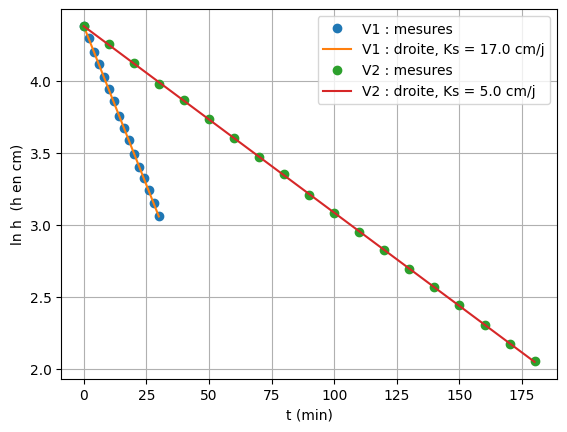

Charge variable, Ks à 20 °C :
  echantillon  Ks_20_cmj  erreur_type_cmj   r2
0          V1     16.995            0.056  1.0
1          V2      4.991            0.009  1.0


In [4]:
resultats = []
plt.figure()
for sid in ["V1", "V2"]:
    donnees = cv[cv["echantillon"] == sid]
    t = donnees["t_s"].to_numpy()
    h = donnees["h_cm"].to_numpy()
    a = donnees["a_cm2"].iloc[0]
    A = donnees["A_cm2"].iloc[0]
    L = donnees["L_cm"].iloc[0]
    T = donnees["T_C"].iloc[0]
    ln_h = np.log(h)

    # droite ln h = ln h0 - (A Ks / (a L)) t : np.polyfit renvoie (pente, ordonnée) et leur matrice de covariance
    coef, cov = np.polyfit(t, ln_h, 1, cov=True)
    pente = coef[0]
    erreur_pente = np.sqrt(cov[0, 0])

    # Ks (cm/s à T) puis à 20 °C en cm/j ; l'erreur type se convertit avec le même facteur
    Ks_cms = -pente * a * L / A
    facteur = viscosite(T) / viscosite(20) * 86400
    Ks_20 = Ks_cms * facteur
    erreur_Ks = erreur_pente * a * L / A * facteur
    ln_h_droite = np.polyval(coef, t)
    r2 = 1 - np.sum((ln_h - ln_h_droite)**2) / np.sum((ln_h - np.mean(ln_h))**2)
    resultats.append([sid, Ks_20, erreur_Ks, r2])

    plt.plot(t / 60, ln_h, "o", label=sid + " : mesures")
    plt.plot(t / 60, ln_h_droite, "-", label=sid + f" : droite, Ks = {Ks_20:.1f} cm/j")

plt.xlabel("t (min)")
plt.ylabel("ln h  (h en cm)")
plt.legend()
plt.grid(True)
plt.show()

res_cv = pd.DataFrame(resultats, columns=["echantillon", "Ks_20_cmj", "erreur_type_cmj", "r2"])
print("Charge variable, Ks à 20 °C :")
print(res_cv.round(3))

**3. Comparaison avec Kozeny–Carman**

In [5]:
# Ks (m/s) de Kozeny-Carman : d = diamètre efficace (m), n = porosité (-), T = température (°C)
def kozeny_carman(d_m, n, T):
    Ks = rho_w * g_pes / viscosite(T) * n**3 / (180 * (1 - n)**2) * d_m**2
    return Ks

lignes = []
for sid in ["S1", "S2", "S3", "S4"]:
    donnees = cc[cc["echantillon"] == sid]
    texture = donnees["texture"].iloc[0]
    d10_m = donnees["d10_mm"].iloc[0] * 1e-3
    n = donnees["n"].iloc[0]
    Ks_KC = kozeny_carman(d10_m, n, 20) * 8.64e6      # m/s -> cm/j
    Ks_mesuree = res_cc.loc[sid, "Ks_moy_cmj"]
    lignes.append([sid, texture, d10_m * 1e3, n, Ks_KC, Ks_mesuree, Ks_mesuree / Ks_KC])

kc = pd.DataFrame(lignes, columns=["echantillon", "texture", "d10_mm", "n", "Ks_KC_cmj", "Ks_mesuree_cmj", "rapport_mesure_KC"])
print(kc.round(2))

  echantillon       texture  d10_mm     n  Ks_KC_cmj  Ks_mesuree_cmj  \
0          S1   sable moyen    0.15  0.38    1506.64         2003.85   
1          S2     sable fin    0.08  0.40     533.72          598.37   
2          S3  loam sableux    0.04  0.42     165.30           97.62   
3          S4          loam    0.02  0.45      56.52           20.18   

   rapport_mesure_KC  
0               1.33  
1               1.12  
2               0.59  
3               0.36  


**Commentaire (instructeur).** Les répétitions à charge constante dispersent de ~5 % (CV) : c'est la précision de la méthode sur un même échantillon, très
inférieure à la variabilité spatiale de $K_s$ (CV > 100 %). La correction de température (18 → 20 °C) vaut +5 % : négligeable
devant cette variabilité, mais indispensable pour comparer des laboratoires. Kozeny–Carman est du bon ordre de grandeur pour les
sables (rapport 0,5–2) mais s'écarte pour les loams : $d_{10}$ ne décrit plus la géométrie des pores fins et la structure
n'est pas prise en compte.

## Exercice 2 — Sol à trois couches : flux et profils de charge  *(≈ 15 min)*

Sable ($K_1 = 50$ cm/j, 30 cm) sur argile ($K_2 = 0{,}5$ cm/j, 10 cm) sur sable ($K_3 = 20$ cm/j, 60 cm) ; lame d'eau de 5 cm en
surface ($H_{haut} = 5$ cm) ; nappe à la base ($z = -100$ cm, $h = 0$, $H_{bas} = -100$ cm).

1. Calculer $K_\perp = \sum L_i / \sum (L_i/K_i)$ et le flux $q = -K_\perp \Delta H/\sum L_i$ (en supposant tout saturé).
2. Calculer couche par couche la perte de charge $|q| L_i/K_i$, puis $H$ et $h = H - z$ aux interfaces ; tracer $H(z)$ et $h(z)$.
   Où la pression devient-elle négative ? Quelle fraction de la perte de charge a lieu dans l'argile ?
3. Nappe perchée : recalculer le flux en imposant $h = 0$ à la base de l'argile ($H = -40$ cm) sur les deux couches supérieures ;
   comparer au cas « tout saturé ».
4. Remplacer l'argile par un loam ($K_2 = 25$ cm/j) : le profil reste-t-il saturé ? Flux ?

**Données du profil**

In [6]:
K = np.array([50.0, 0.5, 20.0])    # conductivités des couches, de haut en bas (cm/j)
L = np.array([30.0, 10.0, 60.0])   # épaisseurs (cm)
H_haut = 5.0                       # charge en surface (lame d'eau de 5 cm), cm
H_bas = -100.0                     # charge à la base (nappe, h = 0 à z = -100 cm), cm

**1. Conductivité équivalente et flux**

In [7]:
# couches en série : K_eq = somme des L / somme des (L / K)
K_eq = L.sum() / np.sum(L / K)

# loi de Darcy sur toute l'épaisseur ; q < 0 : écoulement vers le bas
q = -K_eq * (H_haut - H_bas) / L.sum()
print(f"K_eq = {K_eq:.3f} cm/j ; q = {q:.3f} cm/j (vers le bas)")

K_eq = 4.237 cm/j ; q = -4.449 cm/j (vers le bas)


**2. Profils de charge couche par couche**

              z (cm)  H (cm)  h (cm)
surface          0.0    5.00    5.00
sable/argile   -30.0    2.33   32.33
argile/sable   -40.0  -86.65  -46.65
base          -100.0 -100.00    0.00
Perte de charge par couche (cm) : [ 2.67 88.98 13.35]
Fraction dans l'argile : 85 %
Pression sous l'argile : h = -46.7 cm -> hypothèse saturée violée dans le sable inférieur


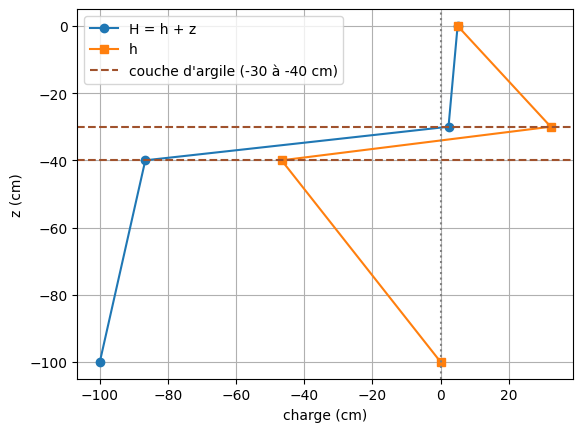

In [8]:
# on part de la surface et on descend : dans chaque couche, H diminue de la perte de charge |q| L_i / K_i
z = [0.0]
H = [H_haut]
for i in range(3):
    perte = abs(q) * L[i] / K[i]
    z.append(z[i] - L[i])
    H.append(H[i] - perte)
z = np.array(z)
H = np.array(H)
h = H - z

tab = pd.DataFrame({"z (cm)": z, "H (cm)": H, "h (cm)": h}, index=["surface", "sable/argile", "argile/sable", "base"])
print(tab.round(2))

pertes = abs(q) * L / K
print("Perte de charge par couche (cm) :", np.round(pertes, 2))
print("Fraction dans l'argile :", round(100 * pertes[1] / pertes.sum()), "%")
print("Pression sous l'argile : h =", round(h[2], 1), "cm -> hypothèse saturée violée dans le sable inférieur")

plt.figure()
plt.plot(H, z, "o-", label="H = h + z")
plt.plot(h, z, "s-", label="h")
plt.axvline(0, color="gray", linestyle=":")
plt.axhline(-30, color="sienna", linestyle="--", label="couche d'argile (-30 à -40 cm)")
plt.axhline(-40, color="sienna", linestyle="--")
plt.xlabel("charge (cm)")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**3. Nappe perchée sur l'argile**

In [9]:
# sable + argile en série entre H_haut = 5 cm et H = -40 cm (h = 0 à la base de l'argile, z = -40 cm)
L_sup = L[0] + L[1]
K_eq2 = L_sup / (L[0] / K[0] + L[1] / K[1])
q2 = -K_eq2 * (H_haut - (-40.0)) / L_sup

# charge à l'interface sable/argile (z = -30 cm) et pression à la base du sable supérieur
H_interface = H_haut - abs(q2) * L[0] / K[0]
h_interface = H_interface - (-30.0)
z2 = np.array([0.0, -30.0, -40.0])
H2 = np.array([H_haut, H_interface, -40.0])
print(f"Nappe perchée : q = {q2:.2f} cm/j (contre {q:.2f} tout saturé) ; h à la base du sable supérieur = {h_interface:.1f} cm")

Nappe perchée : q = -2.18 cm/j (contre -4.45 tout saturé) ; h à la base du sable supérieur = 33.7 cm


**4. Un loam à la place de l'argile**

Avec un loam : K_eq = 25.00 cm/j, q = -26.25 cm/j, h min = 0.0 cm
-> profil saturé partout


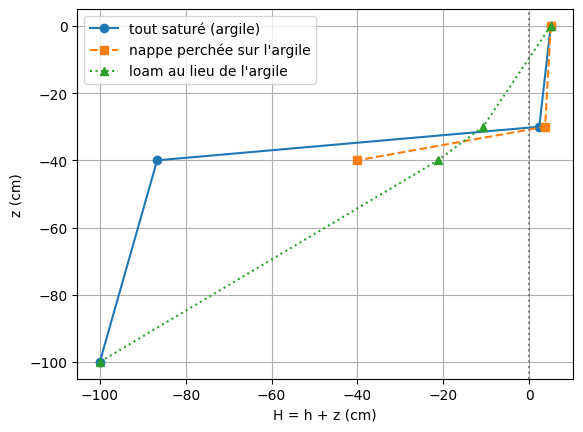

In [10]:
K3 = np.array([50.0, 25.0, 20.0])
K_eq3 = L.sum() / np.sum(L / K3)
q3 = -K_eq3 * (H_haut - H_bas) / L.sum()

# profil de charge couche par couche, comme à l'étape 2
H3 = [H_haut]
for i in range(3):
    perte = abs(q3) * L[i] / K3[i]
    H3.append(H3[i] - perte)
H3 = np.array(H3)
h3 = H3 - z
h3_min = round(h3.min(), 2)
print(f"Avec un loam : K_eq = {K_eq3:.2f} cm/j, q = {q3:.2f} cm/j, h min = {h3_min:.1f} cm")
if h3_min >= 0:
    print("-> profil saturé partout")
else:
    print("-> pression négative : le profil ne reste pas saturé")

plt.figure()
plt.plot(H, z, "o-", label="tout saturé (argile)")
plt.plot(H2, z2, "s--", label="nappe perchée sur l'argile")
plt.plot(H3, z, "^:", label="loam au lieu de l'argile")
plt.axvline(0, color="gray", linestyle=":")
plt.xlabel("H = h + z (cm)")
plt.ylabel("z (cm)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** La couche d'argile absorbe 85 % de la perte de charge et impose le flux (4,45 cm/j) ; sous elle, $h = -47$ cm : le sable inférieur
ne peut pas rester saturé. En réalité une nappe perchée se forme sur l'argile et le flux tombe à 2,2 cm/j (limité par l'argile
avec $h \approx 0$ à sa base). Avec un loam à la place de l'argile, la perte de charge se répartit, $h$ reste positif partout
et le flux atteint ~ 26 cm/j : la couche la moins perméable contrôle tout.

## Exercice 3 — Écartement de drains : Hooghoudt et profondeur équivalente  *(≈ 15 min)*

Équation de Hooghoudt : $L^2 = (8 K_b d_e h + 4 K_a h^2)/q$ (m, j), avec la profondeur équivalente de van der Molen & Wesseling (1991) :

$d_e = \dfrac{\pi L/8}{\ln[L/(\pi r_0)] + F(x)}$, $x = 2\pi D/L$, $F(x) = \sum_{j=1,3,5,\dots} \dfrac{4 e^{-2jx}}{j(1-e^{-2jx})}$ pour $x > 0{,}5$
et $F(x) \approx \pi^2/(4x) + \ln[x/(2\pi)]$ pour $x < 0{,}5$.

1. Programmer `de_vdmw(L, D, r0)` ; vérifier : $L = 20$ m, $D = 1$ m, $r_0 = 0{,}1$ m → $d_e \approx 0{,}87$ m ; $D = 1000$ m → $\approx 1{,}89$ m ;
   $D = 0{,}5$ m → $\approx 0{,}49$ m ($\approx D$).
2. Calculer $L$ par itération de point fixe ($L \to d_e \to L$, boucle `for` avec test d'arrêt, $K_a = K_b = K$) ; retrouver
   $L = 28{,}3$ m pour $q = 7$ mm/j, $K = 0{,}8$ m/j, $h = 0{,}5$ m, $D = 2$ m, $r_0 = 0{,}1$ m.
3. Table de $L$ pour $K \in \{0{,}2 ; 0{,}5 ; 1 ; 2\}$ m/j et $D \in \{0{,}5 ; 1 ; 2 ; 5 ; 1000\}$ m ; graphique $L(K)$ pour chaque $D$.
4. Sensibilité (cas de référence) : variation relative de $L$ pour $K \times 0{,}5$ et $\times 2$, pour $h = 0{,}4$ et $0{,}6$ m,
   et pour $q = 5$ et $10$ mm/j.

**1. Profondeur équivalente de van der Molen et Wesseling**

In [11]:
# profondeur équivalente d_e (m) de Hooghoudt pour un écartement L, une profondeur D de la couche imperméable
# sous les drains et un rayon de drain r0 (unités cohérentes, en m)
def de_vdmw(L, D, r0):
    x = 2 * np.pi * D / L
    if x < 0.5:
        F = np.pi**2 / (4 * x) + np.log(x / (2 * np.pi))
    else:
        j = np.arange(1, 400, 2)                  # termes impairs de la série
        e = np.exp(-2 * j * x)
        F = np.sum(4 * e / (j * (1 - e)))
    de = np.pi * L / (8 * (np.log(L / (np.pi * r0)) + F))
    return de

print("Vérifications d_e :", round(de_vdmw(20, 1, 0.1), 3), round(de_vdmw(20, 1000, 0.1), 3), round(de_vdmw(20, 0.5, 0.1), 3))

Vérifications d_e : 0.872 1.891 0.486


**2. Écartement pour le cas de référence (itération de point fixe)**

In [12]:
q = 0.007    # critère de drainage, m/j
K = 0.8      # conductivité, m/j
h = 0.5      # hauteur de la nappe au milieu de l'écartement, m
D = 2.0      # profondeur de la couche imperméable sous les drains, m
r0 = 0.1     # rayon équivalent du drain, m

# point fixe : avec un L d'essai on calcule d_e, puis un nouveau L par Hooghoudt, jusqu'à ce que L ne change plus
L = 30.0
for it in range(50):
    de = de_vdmw(L, D, r0)
    L_nouveau = np.sqrt((8 * K * de * h + 4 * K * h**2) / q)
    ecart = abs(L_nouveau - L)
    L = L_nouveau
    if ecart < 1e-6:
        break
L_ref = L
print(f"Exemple du cours : L = {L_ref:.2f} m, d_e = {de:.3f} m ({it + 1} itérations)")

Exemple du cours : L = 28.28 m, d_e = 1.500 m (8 itérations)


**3. Table L(K, D) et graphique**

Écartement L (m) pour q = 7 mm/j, h = 0,5 m, r0 = 0,1 m :
           K = 0,2 m/j  K = 0,5 m/j  K = 1 m/j  K = 2 m/j
D = 0,5 m          9.1         14.4       20.5       29.1
D = 1 m           10.9         17.8       25.6       36.7
D = 2 m           12.6         21.7       32.0       46.8
D = 5 m           13.8         26.1       41.0       62.8
D -> inf          13.9         27.6       47.7       83.8


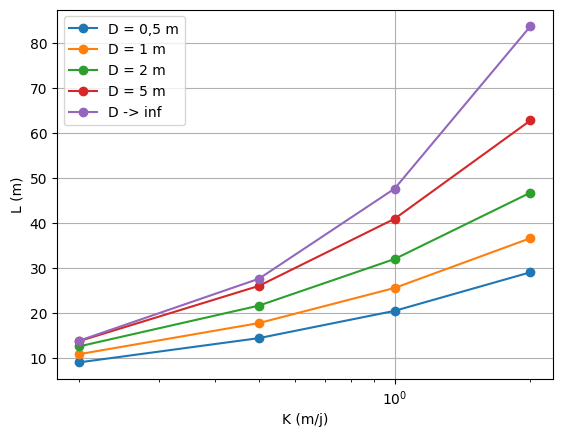

In [13]:
K_liste = [0.2, 0.5, 1.0, 2.0]
D_liste = [0.5, 1.0, 2.0, 5.0, 1000.0]

lignes = []
for D in D_liste:
    ligne = []
    for K in K_liste:
        # même itération de point fixe qu'à l'étape 2
        L = 30.0
        for it in range(50):
            de = de_vdmw(L, D, r0)
            L_nouveau = np.sqrt((8 * K * de * h + 4 * K * h**2) / q)
            ecart = abs(L_nouveau - L)
            L = L_nouveau
            if ecart < 1e-6:
                break
        ligne.append(L)
    lignes.append(ligne)

table = pd.DataFrame(lignes, index=["D = 0,5 m", "D = 1 m", "D = 2 m", "D = 5 m", "D -> inf"],
                     columns=["K = 0,2 m/j", "K = 0,5 m/j", "K = 1 m/j", "K = 2 m/j"])
print("Écartement L (m) pour q = 7 mm/j, h = 0,5 m, r0 = 0,1 m :")
print(table.round(1))

plt.figure()
for k in range(len(D_liste)):
    plt.semilogx(K_liste, lignes[k], "o-", label=table.index[k])
plt.xlabel("K (m/j)")
plt.ylabel("L (m)")
plt.legend()
plt.grid(True)
plt.show()

**4. Sensibilité autour du cas de référence**

In [14]:
# chaque cas : nom, q (m/j), K (m/j), h (m) ; D = 2 m et r0 = 0,1 m comme pour le cas de référence
cas = [["K x 0,5", 0.007, 0.4, 0.5],
       ["K x 2", 0.007, 1.6, 0.5],
       ["h = 0,4 m", 0.007, 0.8, 0.4],
       ["h = 0,6 m", 0.007, 0.8, 0.6],
       ["q = 5 mm/j", 0.005, 0.8, 0.5],
       ["q = 10 mm/j", 0.010, 0.8, 0.5]]

noms = []
L_cas = []
for c in cas:
    q_c = c[1]
    K_c = c[2]
    h_c = c[3]
    L = 30.0
    for it in range(50):
        de = de_vdmw(L, 2.0, 0.1)
        L_nouveau = np.sqrt((8 * K_c * de * h_c + 4 * K_c * h_c**2) / q_c)
        ecart = abs(L_nouveau - L)
        L = L_nouveau
        if ecart < 1e-6:
            break
    noms.append(c[0])
    L_cas.append(L)

sens = pd.DataFrame({"L (m)": L_cas}, index=noms)
sens["variation (%)"] = 100 * (sens["L (m)"] / L_ref - 1)
print(sens.round(1))

             L (m)  variation (%)
K x 0,5       19.1          -32.6
K x 2         41.5           46.6
h = 0,4 m     24.5          -13.3
h = 0,6 m     31.8           12.4
q = 5 mm/j    34.1           20.6
q = 10 mm/j   23.1          -18.3


**Commentaire (instructeur).** $L$ varie comme $\sqrt{K}$ et $\sqrt{1/q}$ (±40 % pour un facteur 2), et à peu près linéairement avec $h$ (±20 % pour ±20 %).
La conductivité, connue au mieux à un facteur 2 près, est donc le paramètre à mesurer en priorité (trou à la tarière, plusieurs
points). La couche imperméable profonde ($D \to \infty$) augmente $L$ jusqu'à 60 % par rapport à $D = 0{,}5$ m pour $K = 2$ m/j : la
prospection de la profondeur du substratum fait partie du dimensionnement.

## Exercice 4 — Laplace 2D par différences finies : écoulement sous une palplanche  *(≈ 15 min)*

Domaine $30 \times 15$ m (grille $61 \times 31$, $\Delta = 0{,}5$ m), $K = 1$ m/j, palplanche en $x = 15$ m fichée à 6 m (elle coupe la
connexion entre les colonnes $i_p - 1$ et $i_p$ jusqu'à $z = -6$ m). Surface : $H = 4$ m à l'amont ($x < 15$), $H = 0$ à l'aval ;
parois latérales et fond imperméables (Neumann : nœud miroir).

1. Résoudre $\nabla^2 H = 0$ par la méthode de Jacobi : à chaque itération, chaque nœud prend la moyenne de ses quatre voisins,
   $H_{i,j} = (H_{i-1,j} + H_{i+1,j} + H_{i,j-1} + H_{i,j+1})/4$, puis on réimpose les conditions aux limites ; arrêt quand
   $\max|\Delta H| < 10^{-6}$ m. Combien d'itérations ?
2. Tracer les équipotentielles et le champ de flux ($q_x = -K\,\partial H/\partial x$, $q_z = -K\,\partial H/\partial z$).
3. Calculer le débit de fuite $Q$ (m³/j par m) par la surface aval, le débit entrant à l'amont (bilan), le facteur de forme
   $Q/(K\Delta H) = N_f/N_d$ et le gradient hydraulique de sortie à l'aval, contre la palplanche (à comparer au gradient critique $\approx 1$).

**Maillage et conditions aux limites**

In [15]:
nx = 61        # nombre de colonnes (x de 0 à 30 m)
nz = 31        # nombre de lignes (z de 0 à -15 m) ; la ligne 0 est la surface
dx = 0.5       # pas de la grille, m (le même en x et en z)
K = 1.0        # conductivité, m/j
H_am = 4.0     # charge imposée en surface à l'amont, m
H_av = 0.0     # charge imposée en surface à l'aval, m
ip = 30        # la palplanche sépare les colonnes ip-1 et ip (x = 15 m)
zp = 12        # elle descend jusqu'à la ligne zp (z = -6 m)

# tableau H avec une rangée de noeuds fictifs tout autour : le noeud réel (j, i) est à H[j + 1, i + 1]
# les noeuds fictifs servent à écrire la condition de bord imperméable (miroir)
H = np.full((nz + 2, nx + 2), 2.0)       # valeur initiale : 2 m partout
H[1, 1:ip + 1] = H_am                    # surface amont (colonnes 0 à ip-1)
H[1, ip + 1:nx + 1] = H_av               # surface aval (colonnes ip à nx-1)
print("taille du tableau H (avec les noeuds fictifs) :", H.shape)

taille du tableau H (avec les noeuds fictifs) : (33, 63)


**1. Itérations de Jacobi**

In [16]:
tol = 1e-6
for it in range(50000):
    # valeurs des quatre voisins de chaque noeud réel (tableaux nz x nx)
    haut = H[0:-2, 1:-1]
    bas = H[2:, 1:-1]
    gauche = H[1:-1, 0:-2].copy()
    droite = H[1:-1, 2:].copy()

    # palplanche : sur les lignes 0 à zp, les colonnes ip-1 et ip ne se voient pas (voisin remplacé par le miroir)
    droite[0:zp + 1, ip - 1] = gauche[0:zp + 1, ip - 1]
    gauche[0:zp + 1, ip] = droite[0:zp + 1, ip]

    # moyenne des quatre voisins (schéma de Jacobi : on utilise les valeurs de l'itération précédente)
    H_nouveau = H.copy()
    H_nouveau[1:-1, 1:-1] = 0.25 * (haut + bas + gauche + droite)

    # conditions aux limites : charge imposée en surface, miroirs sur le fond et les parois latérales
    H_nouveau[1, 1:ip + 1] = H_am
    H_nouveau[1, ip + 1:nx + 1] = H_av
    H_nouveau[-1, :] = H_nouveau[-3, :]
    H_nouveau[:, 0] = H_nouveau[:, 2]
    H_nouveau[:, -1] = H_nouveau[:, -3]

    # test de convergence : plus grand changement entre deux itérations
    ecart = np.abs(H_nouveau - H).max()
    H = H_nouveau
    if ecart < tol:
        break

print(f"Jacobi : convergence en {it + 1} itérations (max |dH| = {ecart:.1e} m)")
Hs = H[1:-1, 1:-1]       # les noeuds réels seulement (nz x nx)

Jacobi : convergence en 6198 itérations (max |dH| = 1.0e-06 m)


**2. Équipotentielles et champ de flux**

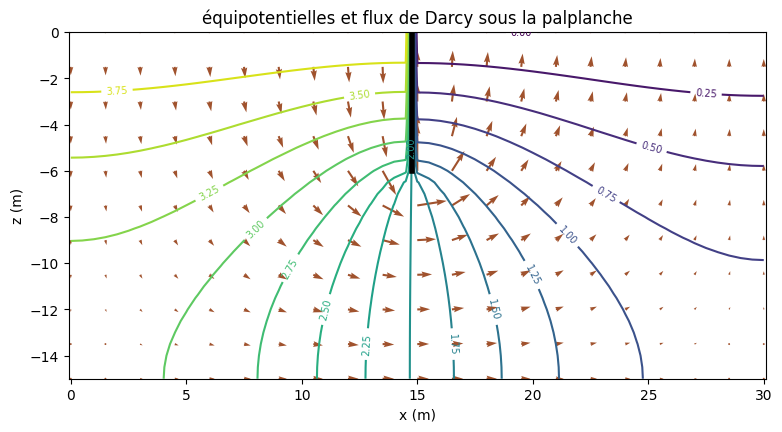

In [17]:
X = np.arange(nx) * dx       # abscisses des colonnes, m
Z = -np.arange(nz) * dx      # cotes des lignes, m (z = 0 en surface)

# flux de Darcy par différences centrées ; la ligne j-1 est au-dessus de la ligne j (z vers le haut)
qx = np.zeros((nz, nx))
qz = np.zeros((nz, nx))
qx[:, 1:-1] = -K * (Hs[:, 2:] - Hs[:, :-2]) / (2 * dx)
qz[1:-1, :] = -K * (Hs[:-2, :] - Hs[2:, :]) / (2 * dx)
# pas de flux horizontal à travers la palplanche (la différence centrée n'y a pas de sens)
qx[0:zp + 1, ip - 1] = 0.0
qx[0:zp + 1, ip] = 0.0

plt.figure(figsize=(9, 4.5))
cs = plt.contour(X, Z, Hs, levels=np.linspace(0, 4, 17))
plt.clabel(cs, fmt="%.2f", fontsize=7)
plt.quiver(X[::3], Z[::3], qx[::3, ::3], qz[::3, ::3], color="sienna", scale=8, width=0.003)
plt.plot([X[ip] - dx / 2, X[ip] - dx / 2], [0, Z[zp]], "k-", linewidth=4)     # la palplanche
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("équipotentielles et flux de Darcy sous la palplanche")
plt.show()

**3. Débit de fuite, bilan, facteur de forme et gradient de sortie**

In [18]:
# flux vertical à la surface (> 0 vers le haut), entre la ligne 0 (surface) et la ligne 1
q_surf = -K * (Hs[0, :] - Hs[1, :]) / dx

# débit sortant côté aval et débit entrant côté amont (m³/j par m de longueur d'ouvrage)
Q_out = np.sum(q_surf[ip:]) * dx
Q_in = -np.sum(q_surf[:ip]) * dx
bilan = 100 * abs(Q_in - Q_out) / Q_out
print(f"Débit de fuite Q = {Q_out:.3f} m³/j par m ; entrée = {Q_in:.3f} ; écart de bilan = {bilan:.2f} %")

# facteur de forme et gradient de sortie contre la palplanche (colonne ip, côté aval)
facteur_forme = Q_out / (K * (H_am - H_av))
print(f"Facteur de forme Q/(K dH) = Nf/Nd = {facteur_forme:.3f}")
i_sortie = (Hs[1, ip] - Hs[0, ip]) / dx
print(f"Gradient de sortie contre la palplanche (aval) : i = {i_sortie:.2f}")
if i_sortie > 1:
    print("-> gradient critique dépassé : renard possible !")
else:
    print("-> coefficient de sécurité par rapport au gradient critique (1) :", round(1 / i_sortie, 1))

Débit de fuite Q = 2.032 m³/j par m ; entrée = 2.031 ; écart de bilan = 0.02 %
Facteur de forme Q/(K dH) = Nf/Nd = 0.508
Gradient de sortie contre la palplanche (aval) : i = 0.19
-> coefficient de sécurité par rapport au gradient critique (1) : 5.4


**Commentaire (instructeur).** Jacobi converge lentement (plusieurs milliers d'itérations, en moins d'une seconde sur cette grille) : chaque itération ne
propage l'information que d'une maille. Gauss–Seidel ou la sur-relaxation (SOR) feraient 2 à 10 fois mieux, pour la même solution.
Le bilan (entrée = sortie à mieux que 1 %) valide la discrétisation. Le facteur de forme $N_f/N_d \approx 0{,}5$ est celui que
l'on obtient en traçant le réseau à la main (≈ 5 tubes pour 10 chutes). Le gradient de sortie contre la palplanche (~0,2 sur
cette grille de 0,5 m) reste loin du gradient critique, mais il est sous-estimé par la maille grossière : le raffinement près du
pied de la palplanche (singularité) l'augmente nettement et doit être fait dans un projet réel.

## Exercice 5 — Bonus — milieu anisotrope  *(≈ facultatif)*

Refaire l'exercice 4 avec $K_h = 4$ m/j et $K_v = 1$ m/j : le schéma devient
$H_{i,j} = [K_h(H_{i+1,j} + H_{i-1,j}) + K_v(H_{i,j+1} + H_{i,j-1})]/[2(K_h + K_v)]$ ($\Delta x = \Delta z$).
Comparer le débit de fuite (avec $q_z = -K_v\,\partial H/\partial z$) et l'allure des équipotentielles au cas isotrope.

**Jacobi avec Kh et Kv**

Anisotrope (Kh = 4, Kv = 1) : 9003 itérations ; Q = 3.066 m³/j par m contre 2.032 isotrope (K = 1)
Q / (sqrt(Kh Kv) dH) = 0.383  (facteur de forme du domaine transformé x' = x/2)


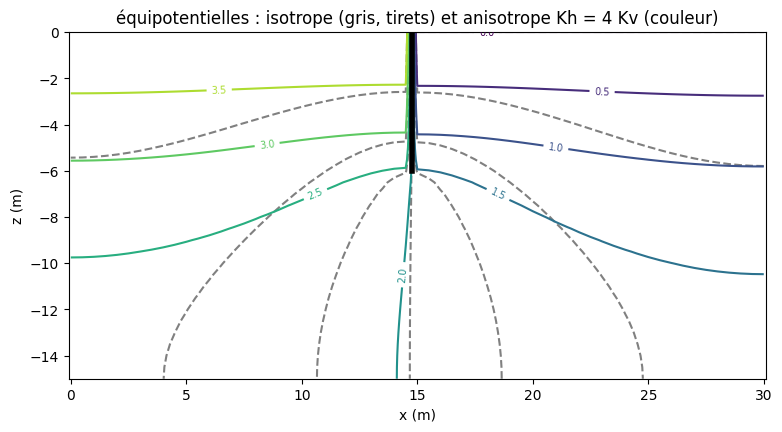

In [19]:
Kh = 4.0
Kv = 1.0
H2 = np.full((nz + 2, nx + 2), 2.0)
H2[1, 1:ip + 1] = H_am
H2[1, ip + 1:nx + 1] = H_av

for it in range(50000):
    haut = H2[0:-2, 1:-1]
    bas = H2[2:, 1:-1]
    gauche = H2[1:-1, 0:-2].copy()
    droite = H2[1:-1, 2:].copy()
    droite[0:zp + 1, ip - 1] = gauche[0:zp + 1, ip - 1]
    gauche[0:zp + 1, ip] = droite[0:zp + 1, ip]

    # moyenne pondérée par Kh (voisins horizontaux) et Kv (voisins verticaux)
    H2_nouveau = H2.copy()
    H2_nouveau[1:-1, 1:-1] = (Kh * (gauche + droite) + Kv * (haut + bas)) / (2 * (Kh + Kv))
    H2_nouveau[1, 1:ip + 1] = H_am
    H2_nouveau[1, ip + 1:nx + 1] = H_av
    H2_nouveau[-1, :] = H2_nouveau[-3, :]
    H2_nouveau[:, 0] = H2_nouveau[:, 2]
    H2_nouveau[:, -1] = H2_nouveau[:, -3]
    ecart = np.abs(H2_nouveau - H2).max()
    H2 = H2_nouveau
    if ecart < tol:
        break

Hs2 = H2[1:-1, 1:-1]
q_surf2 = -Kv * (Hs2[0, :] - Hs2[1, :]) / dx
Q2 = np.sum(q_surf2[ip:]) * dx
print(f"Anisotrope (Kh = 4, Kv = 1) : {it + 1} itérations ; Q = {Q2:.3f} m³/j par m contre {Q_out:.3f} isotrope (K = 1)")
print(f"Q / (sqrt(Kh Kv) dH) = {Q2 / (np.sqrt(Kh * Kv) * (H_am - H_av)):.3f}  (facteur de forme du domaine transformé x' = x/2)")

plt.figure(figsize=(9, 4.5))
plt.contour(X, Z, Hs, levels=np.linspace(0, 4, 9), colors="gray", linestyles="--")
cs = plt.contour(X, Z, Hs2, levels=np.linspace(0, 4, 9))
plt.clabel(cs, fmt="%.1f", fontsize=7)
plt.plot([X[ip] - dx / 2, X[ip] - dx / 2], [0, Z[zp]], "k-", linewidth=4)
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("équipotentielles : isotrope (gris, tirets) et anisotrope Kh = 4 Kv (couleur)")
plt.show()

**Commentaire (instructeur).** Avec $K_h = 4K_v$, les équipotentielles s'aplatissent (l'eau contourne la palplanche plus loin horizontalement) et le débit augmente d'un facteur ~1,5 : moins que $\sqrt{K_h K_v} = 2$, parce que le facteur de forme du domaine transformé ($x' = x/2$, deux fois moins large pour la même profondeur) est plus petit (0,38 contre 0,51) : la palplanche barre une part relativement plus grande de la section d'écoulement.

## Pour aller plus loin

* Exercice 2 : traiter le cas non saturé sous l'argile avec $K(h)$ de van Genuchten–Mualem (Jour 5) et comparer au flux de la nappe perchée.
* Exercice 3 : ajouter la formule non permanente de Glover–Dumm pour la vidange après une pluie de 40 mm.
* Exercice 4 : accélérer la convergence (Gauss–Seidel, sur-relaxation), raffiner la grille ($\Delta = 0{,}25$ m) et étudier la
  convergence du gradient de sortie ; ajouter un radier amont.